<a href="https://colab.research.google.com/github/BelenGutierrezG/BDAA_SEM07/blob/develop/Copia_de_25%2C05%2C03%2Cv4C_TiposDeClustering_Stocks_ECR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GUIA DE LABORATORIO: Casos Prácticos de Machine Learning No Supervisado (Clustering)**

## **APELLIDOS, Nombres:** GUTIERREZ GARCIA, Angela Belen


In [ ]:
# NumPy
import numpy as np
from numpy import where

# MatPlotLib
import matplotlib.pyplot as plt

from matplotlib import pyplot
from matplotlib import style
#plt.style.use('ggplot')
#plt.style.use('seaborn-darkgrid')
plt.style.use('fivethirtyeight')

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 10,5
plt.rcParams['axes.facecolor'] = 'white'

# Seaborn
import seaborn as sns

import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

#Pandas
import pandas as pd
from datetime import timedelta
(pd.Timestamp.now() - timedelta(hours=5)).strftime('Hora de Actualización: %Y-%m-%d %H:%M:%S Hora en Lima (GMT-5).')
#pd.Timestamp.today().strftime('%Y-%m-%d %H:%M:%S') # Se capta la fecha y hora actual

'Hora de Actualización: 2025-05-03 17:12:32 Hora en Lima (GMT-5).'

# **Librerías especiales necesarias:**

In [ ]:
from scipy.stats import zscore
zscore

<function scipy.stats._stats_py.zscore(a, axis=0, ddof=0, nan_policy='propagate')>

In [ ]:
from sklearn.datasets import make_classification
make_classification

<function sklearn.datasets._samples_generator.make_classification(n_samples=100, n_features=20, *, n_informative=2, n_redundant=2, n_repeated=0, n_classes=2, n_clusters_per_class=2, weights=None, flip_y=0.01, class_sep=1.0, hypercube=True, shift=0.0, scale=1.0, shuffle=True, random_state=None)>

# **DATASETS A UTILIZAR:**

## **DATASET 1: GENERAR DE DATOS SINTETICOS**

**Generar un problema de clasificación aleatorio de n clases.**

Inicialmente, esto crea grupos de puntos distribuidos normalmente (desviación estándar = 1) alrededor de los vértices de un hipercubo de n_informative dimensiones con lados de longitud 2*class_sep y asigna un número igual de grupos a cada clase. Introduce interdependencia entre estas características y agrega varios tipos de ruido adicional a los datos.



In [ ]:
X, y = make_classification()
# n_samples=100, n_features=20, *, n_informative=2, n_redundant=2, n_repeated=0,
# n_classes=2
X

array([[-1.0709401 ,  0.82093066, -0.64027536, ...,  0.62703484,
         0.41412951, -1.55060018],
       [-0.81026674,  1.13813633,  0.79215675, ..., -1.47281933,
        -0.51395656,  0.79741632],
       [ 1.89597201, -2.2867161 ,  0.61006934, ..., -1.44350834,
        -0.74382067,  0.56927641],
       ...,
       [ 2.51466242,  0.38080385, -0.95931438, ..., -2.72834333,
         0.67399626,  0.17752111],
       [-1.1057371 ,  1.45295377,  1.14594413, ..., -0.09986448,
        -0.12098511,  0.20295266],
       [-0.77523747,  0.81540724, -0.13135226, ...,  0.945555  ,
         0.74778628, -0.61310354]])

In [ ]:
len(X)

100

In [ ]:
display( y[:10] )

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
len(y)

100

In [ ]:
# Creamos un dataset sintetico que usaremos en todos los ejemplos
X, y = make_classification( n_samples=1000,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_classes = 3,
                            n_clusters_per_class=1, random_state=37)
X

array([[-0.71886442, -0.87404642],
       [-1.3806185 ,  0.60156581],
       [-2.14538462, -1.44901195],
       ...,
       [-1.15507929,  0.99925655],
       [ 0.83760353, -1.16513746],
       [-0.12479361, -0.69656409]])

In [ ]:
len(X)

1000

In [ ]:
display( y[:10] )

array([2, 1, 2, 1, 1, 0, 1, 2, 2, 2])

In [ ]:
len(y)

1000

### Antes de Transformaciones

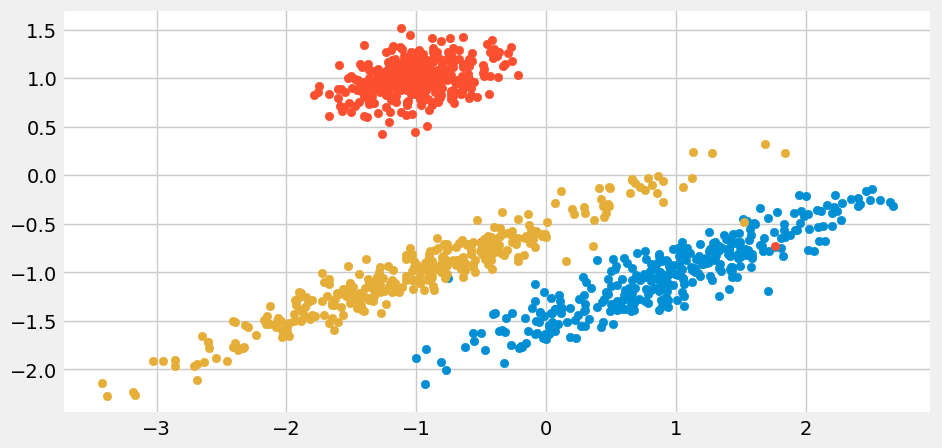

In [ ]:
# Creamos un diagrama de dispersion iterando por cada clase
for class_value in range(3):
 # obtenemos los indices
 row_ix = where(y == class_value)
 # creamos el diagrama
 pyplot.scatter(X[row_ix, 0], X[row_ix, 1])
# mostramos la imagen
pyplot.show()

### TRANSFORMACION - PRE-PROCESAMIENTO:

In [ ]:
# Importante! Reescalar los datos (por ejemplo con una puntuacion Z)
X = zscore(X, axis=0)
X

array([[-0.32400631, -0.52080949],
       [-0.90027689,  0.93326211],
       [-1.5662527 , -1.08738181],
       ...,
       [-0.70387218,  1.32514746],
       [ 1.03140156, -0.80765126],
       [ 0.19332413, -0.345918  ]])

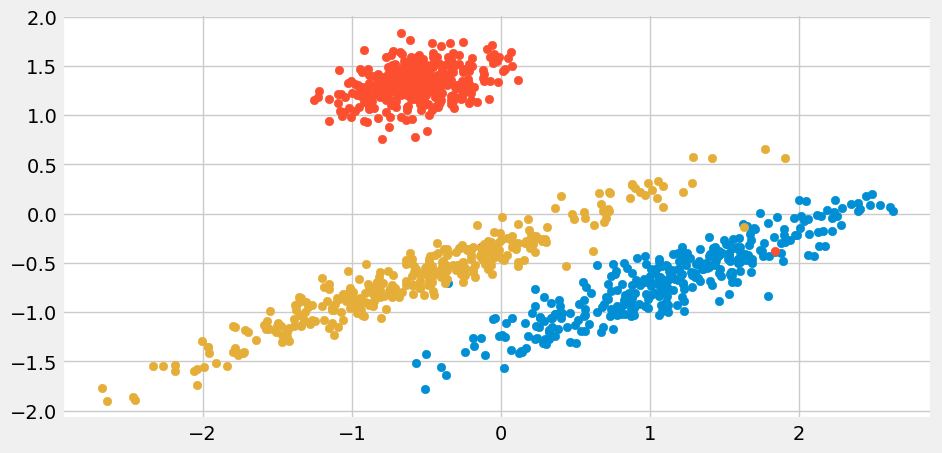

In [ ]:
# Creamos un diagrama de dispersion iterando por cada clase
for class_value in range(3):
 # obtenemos los indices
 row_ix = where(y == class_value)
 # creamos el diagrama
 pyplot.scatter(X[row_ix, 0], X[row_ix, 1])
# mostramos la imagen
pyplot.show()

## **DATASET 2: ACCIONES DE BOLSA DE VALORES**

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/tatsath/fin-ml/master/Chapter%208%20-%20Unsup.%20Learning%20-%20Clustering/Data_MasterTemplate.csv", parse_dates=True, index_col=0)
df

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,DWDP,...,NKE,PFE,PG,TRV,UTX,UNH,VZ,V,WMT,WBA
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,29.847043,35.476634,3.530576,26.650218,14.560887,21.582046,43.003876,16.983583,23.522220,NaN,...,4.701180,16.746856,32.227726,20.158885,21.319030,5.841355,22.564221,NaN,47.337599,21.713237
2000-01-04,28.661131,34.134275,3.232839,26.610431,14.372251,21.582046,40.577200,17.040950,24.899860,NaN,...,4.445214,16.121738,31.596399,19.890099,20.445803,5.766368,21.833915,NaN,45.566248,20.907354
2000-01-05,30.122175,33.959430,3.280149,28.473758,14.914205,22.049145,40.895453,17.228147,25.781550,NaN,...,4.702157,16.415912,31.325831,20.085579,20.254784,5.753327,22.564221,NaN,44.503437,21.097421
2000-01-06,31.877325,33.959430,2.996290,28.553331,15.459153,22.903343,39.781569,17.210031,24.899860,NaN,...,4.677733,16.972739,32.438168,20.122232,20.998392,5.964159,22.449405,NaN,45.126952,20.527220
2000-01-07,32.509812,34.433913,3.138219,29.382213,15.962182,23.305926,42.128682,18.342270,24.506249,NaN,...,4.677733,18.123166,35.023602,20.922479,21.830687,6.662948,22.282692,NaN,48.535033,21.051805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-31,200.300000,102.700000,166.440000,385.620000,133.160000,114.650000,47.290000,48.130000,111.520000,53.81,...,81.880000,42.450000,96.470000,125.540000,118.070000,270.200000,55.060000,135.01,95.830000,72.260000
2019-02-01,199.160000,103.060000,166.520000,387.430000,130.910000,118.370000,47.340000,48.700000,111.300000,53.47,...,81.510000,42.880000,97.470000,126.490000,118.980000,268.720000,54.550000,140.15,93.860000,71.880000
2019-02-04,200.210000,103.420000,171.250000,397.000000,130.880000,119.740000,47.350000,49.250000,111.800000,53.13,...,81.990000,42.440000,98.030000,126.040000,119.140000,268.210000,54.040000,141.50,94.770000,71.460000


from matplotlib import pyplot as plt
df['MMM'].plot(kind='hist', bins=20, title='MMM')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['AXP'].plot(kind='hist', bins=20, title='AXP')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['AAPL'].plot(kind='hist', bins=20, title='AAPL')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['BA'].plot(kind='hist', bins=20, title='BA')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='BA', y='CAT', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
df['MMM'].plot(kind='line', figsize=(8, 4), title='MMM')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['AXP'].plot(kind='line', figsize=(8, 4), title='AXP')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['AAPL'].plot(kind='line', figsize=(8, 4), title='AAPL')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
df['BA'].plot(kind='line', figsize=(8, 4), title='BA')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# Dropping 'Not a Number' columns for Dow Chemicals (DWDP) and Visa (V)
# Eliminación de las columnas "No es un número" para Dow Chemicals (DWDP) y Visa (V)
df.drop(['DWDP', 'V'], axis=1, inplace=True)
df.head(2)

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,MSFT,NKE,PFE,PG,TRV,UTX,UNH,VZ,WMT,WBA
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,29.847043,35.476634,3.530576,26.650218,14.560887,21.582046,43.003876,16.983583,23.52222,23.862240,...,38.135101,4.701180,16.746856,32.227726,20.158885,21.319030,5.841355,22.564221,47.337599,21.713237
2000-01-04,28.661131,34.134275,3.232839,26.610431,14.372251,21.582046,40.577200,17.040950,24.89986,23.405167,...,36.846046,4.445214,16.121738,31.596399,19.890099,20.445803,5.766368,21.833915,45.566248,20.907354


In [ ]:
# Copying the dataframe to add features
# Copiar el marco de datos para añadir características
data = pd.DataFrame(df.copy())
data.head(2)

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,MSFT,NKE,PFE,PG,TRV,UTX,UNH,VZ,WMT,WBA
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,29.847043,35.476634,3.530576,26.650218,14.560887,21.582046,43.003876,16.983583,23.52222,23.862240,...,38.135101,4.701180,16.746856,32.227726,20.158885,21.319030,5.841355,22.564221,47.337599,21.713237
2000-01-04,28.661131,34.134275,3.232839,26.610431,14.372251,21.582046,40.577200,17.040950,24.89986,23.405167,...,36.846046,4.445214,16.121738,31.596399,19.890099,20.445803,5.766368,21.833915,45.566248,20.907354


In [ ]:
# Daily Returns
# Daily Log Returns (%)

# Rendimiento diario
# Rendimiento diario (%)
datareturns = np.log(data / data.shift(1))

In [ ]:
datareturns

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,MSFT,NKE,PFE,PG,TRV,UTX,UNH,VZ,WMT,WBA
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,-0.040544,-0.038572,-0.088100,-0.001494,-0.013040,0.000000,-0.058084,0.003372,0.056917,-0.019340,...,-0.034387,-0.055986,-0.038042,-0.019784,-0.013423,-0.041822,-0.012920,-0.032901,-0.038138,-0.037821
2000-01-05,0.049720,-0.005135,0.014528,0.067680,0.037015,0.021412,0.007813,0.010925,0.034797,0.048536,...,0.010511,0.056193,0.018083,-0.008600,0.009780,-0.009387,-0.002264,0.032901,-0.023601,0.009050
2000-01-06,0.056633,0.000000,-0.090514,0.002791,0.035887,0.038009,-0.027615,-0.001052,-0.034797,0.055013,...,-0.034050,-0.005208,0.033357,0.034893,0.001823,0.036055,0.035990,-0.005101,0.013913,-0.027399
2000-01-07,0.019647,0.013875,0.046281,0.028616,0.032021,0.017425,0.057325,0.063716,-0.015934,-0.002939,...,0.013006,0.000000,0.065583,0.076686,0.038999,0.038871,0.110794,-0.007454,0.072806,0.025234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-31,0.005156,0.000292,0.007175,-0.005431,0.023171,0.014408,0.012341,0.005626,0.012542,0.013602,...,-0.018501,0.007355,0.029152,0.020421,-0.002705,-0.008854,-0.000629,0.019439,0.010806,0.009036
2019-02-01,-0.005708,0.003499,0.000481,0.004683,-0.017041,0.031931,0.001057,0.011773,-0.001975,0.035392,...,-0.015926,-0.004529,0.010079,0.010313,0.007539,0.007678,-0.005492,-0.009306,-0.020771,-0.005273
2019-02-04,0.005258,0.003487,0.028009,0.024401,-0.000229,0.011507,0.000211,0.011230,0.004482,-0.014595,...,0.028392,0.005872,-0.010314,0.005729,-0.003564,0.001344,-0.001900,-0.009393,0.009649,-0.005860


from matplotlib import pyplot as plt
datareturns['MMM'].plot(kind='hist', bins=20, title='MMM')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
datareturns['AXP'].plot(kind='hist', bins=20, title='AXP')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
datareturns['AAPL'].plot(kind='hist', bins=20, title='AAPL')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
datareturns['BA'].plot(kind='hist', bins=20, title='BA')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
datareturns.plot(kind='scatter', x='BA', y='CAT', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
datareturns['MMM'].plot(kind='line', figsize=(8, 4), title='MMM')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
datareturns['AXP'].plot(kind='line', figsize=(8, 4), title='AXP')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
datareturns['AAPL'].plot(kind='line', figsize=(8, 4), title='AAPL')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
datareturns['BA'].plot(kind='line', figsize=(8, 4), title='BA')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
datareturns_log = pd.DataFrame(datareturns.copy())

In [ ]:
# Daily Linear Returns (%)
datareturns = data.pct_change(1)
datareturns

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,MSFT,NKE,PFE,PG,TRV,UTX,UNH,VZ,WMT,WBA
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04,-0.039733,-0.037838,-0.084331,-0.001493,-0.012955,0.000000,-0.056429,0.003378,0.058568,-0.019155,...,-0.033802,-0.054447,-0.037327,-0.019590,-0.013333,-0.040960,-0.012837,-0.032366,-0.037420,-0.037115
2000-01-05,0.050976,-0.005122,0.014634,0.070022,0.037708,0.021643,0.007843,0.010985,0.035409,0.049733,...,0.010567,0.057802,0.018247,-0.008563,0.009828,-0.009343,-0.002262,0.033448,-0.023325,0.009091
2000-01-06,0.058268,0.000000,-0.086538,0.002795,0.036539,0.038741,-0.027237,-0.001052,-0.034198,0.056555,...,-0.033477,-0.005194,0.033920,0.035509,0.001825,0.036713,0.036645,-0.005088,0.014011,-0.027027
2000-01-07,0.019841,0.013972,0.047368,0.029029,0.032539,0.017577,0.059000,0.065789,-0.015808,-0.002935,...,0.013091,0.000000,0.067781,0.079703,0.039769,0.039636,0.117165,-0.007426,0.075522,0.025556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-31,0.005169,0.000292,0.007201,-0.005416,0.023442,0.014512,0.012417,0.005641,0.012621,0.013695,...,-0.018331,0.007382,0.029582,0.020631,-0.002701,-0.008815,-0.000629,0.019630,0.010865,0.009077
2019-02-01,-0.005691,0.003505,0.000481,0.004694,-0.016897,0.032447,0.001057,0.011843,-0.001973,0.036026,...,-0.015800,-0.004519,0.010130,0.010366,0.007567,0.007707,-0.005477,-0.009263,-0.020557,-0.005259
2019-02-04,0.005272,0.003493,0.028405,0.024701,-0.000229,0.011574,0.000211,0.011294,0.004492,-0.014489,...,0.028799,0.005889,-0.010261,0.005745,-0.003558,0.001345,-0.001898,-0.009349,0.009695,-0.005843


from matplotlib import pyplot as plt
datareturns['MMM'].plot(kind='hist', bins=20, title='MMM')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
datareturns['AXP'].plot(kind='hist', bins=20, title='AXP')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
datareturns['AAPL'].plot(kind='hist', bins=20, title='AAPL')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
datareturns['BA'].plot(kind='hist', bins=20, title='BA')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
datareturns.plot(kind='scatter', x='BA', y='CAT', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
datareturns['MMM'].plot(kind='line', figsize=(8, 4), title='MMM')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
datareturns['AXP'].plot(kind='line', figsize=(8, 4), title='AXP')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
datareturns['AAPL'].plot(kind='line', figsize=(8, 4), title='AAPL')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
datareturns['BA'].plot(kind='line', figsize=(8, 4), title='BA')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# Dow Jones Equal Weighted rETURN
datareturns["MEDIA"] = datareturns.mean(axis=1)
datareturns["MEDIA"].head(3)

,MEDIA
Date,
2000-01-03,NaN
2000-01-04,-0.031058
2000-01-05,0.019281


In [ ]:
# Data Raw
data_raw = datareturns
data_raw.dropna(how='all', inplace=True)
data_raw

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,NKE,PFE,PG,TRV,UTX,UNH,VZ,WMT,WBA,MEDIA
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,-0.039733,-0.037838,-0.084331,-0.001493,-0.012955,0.000000,-0.056429,0.003378,0.058568,-0.019155,...,-0.054447,-0.037327,-0.019590,-0.013333,-0.040960,-0.012837,-0.032366,-0.037420,-0.037115,-0.031058
2000-01-05,0.050976,-0.005122,0.014634,0.070022,0.037708,0.021643,0.007843,0.010985,0.035409,0.049733,...,0.057802,0.018247,-0.008563,0.009828,-0.009343,-0.002262,0.033448,-0.023325,0.009091,0.019281
2000-01-06,0.058268,0.000000,-0.086538,0.002795,0.036539,0.038741,-0.027237,-0.001052,-0.034198,0.056555,...,-0.005194,0.033920,0.035509,0.001825,0.036713,0.036645,-0.005088,0.014011,-0.027027,0.002579
2000-01-07,0.019841,0.013972,0.047368,0.029029,0.032539,0.017577,0.059000,0.065789,-0.015808,-0.002935,...,0.000000,0.067781,0.079703,0.039769,0.039636,0.117165,-0.007426,0.075522,0.025556,0.035668
2000-01-10,-0.004864,0.014436,-0.017588,-0.013992,-0.032827,-0.026907,0.036827,-0.031934,0.152586,-0.014010,...,0.016917,-0.001739,-0.005150,-0.018102,0.009844,-0.017289,-0.005271,-0.018248,0.029252,0.003378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-31,0.005169,0.000292,0.007201,-0.005416,0.023442,0.014512,0.012417,0.005641,0.012621,0.013695,...,0.007382,0.029582,0.020631,-0.002701,-0.008815,-0.000629,0.019630,0.010865,0.009077,0.004760
2019-02-01,-0.005691,0.003505,0.000481,0.004694,-0.016897,0.032447,0.001057,0.011843,-0.001973,0.036026,...,-0.004519,0.010130,0.010366,0.007567,0.007707,-0.005477,-0.009263,-0.020557,-0.005259,0.003465
2019-02-04,0.005272,0.003493,0.028405,0.024701,-0.000229,0.011574,0.000211,0.011294,0.004492,-0.014489,...,0.005889,-0.010261,0.005745,-0.003558,0.001345,-0.001898,-0.009349,0.009695,-0.005843,0.004806


In [ ]:
# Normalizing the returns
# Normalizar los rendimientos

data = (data_raw - data_raw.mean()) / data_raw.std()
data

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,NKE,PFE,PG,TRV,UTX,UNH,VZ,WMT,WBA,MEDIA
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,-2.783305,-1.714531,-3.315064,-0.118649,-0.672149,-0.030177,-2.304726,0.236964,3.089027,-1.283097,...,-2.927985,-2.410473,-1.504783,-0.763609,-2.479568,-0.698935,-2.097284,-2.506437,-2.167895,-2.739489
2000-01-05,3.491453,-0.250475,0.522450,3.667073,1.828679,1.321853,0.305449,0.823741,1.857074,3.247575,...,3.023666,1.148279,-0.671468,0.510782,-0.588825,-0.164440,2.128033,-1.568817,0.502376,1.631646
2000-01-06,3.995818,-0.021248,-3.400666,0.108313,1.770951,2.389941,-1.119210,-0.104682,-1.845881,3.696220,...,-0.316511,2.151911,2.659281,0.070428,2.165327,1.801922,-0.346058,0.914757,-1.584911,0.181378
2000-01-07,1.337698,0.604016,1.791770,1.497066,1.573522,1.067883,2.382987,5.050971,-0.867545,-0.216324,...,-0.041103,4.320217,5.999317,2.158221,2.340150,5.871398,-0.496143,5.006585,1.453883,3.054606
2000-01-10,-0.371257,0.624764,-0.727008,-0.780316,-1.653060,-1.711071,1.482524,-2.486755,8.090552,-0.944732,...,0.855881,-0.131547,-0.413525,-1.026003,0.558540,-0.923939,-0.357794,-1.231132,1.667529,0.250687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-31,0.322746,-0.008172,0.234227,-0.326336,1.124453,0.876383,0.491200,0.411568,0.644814,0.877378,...,0.350298,1.874094,1.534865,-0.178592,-0.557248,-0.081917,1.240863,0.705513,0.501569,0.370734
2019-02-01,-0.428509,0.135620,-0.026372,0.208846,-0.866733,1.996753,0.029868,0.889907,-0.131558,2.346087,...,-0.280697,0.628473,0.759112,0.386393,0.430778,-0.326969,-0.614046,-1.384734,-0.326905,0.258311
2019-02-04,0.329890,0.135072,1.056435,1.267959,-0.043981,0.692840,-0.004491,0.847538,0.212369,-0.976238,...,0.271134,-0.677264,0.409911,-0.225725,0.050294,-0.146058,-0.619605,0.627703,-0.360672,0.374712


# **MODELO(S):** Modelamiento: Crear modelo, FIT (Ajustar, Entrenar), PREDICT (generar valores ajustados y/o predicción)

---



## **`MODELO A: CLUSTERING JERARQUICO - de la Data Sintética`**

## Hierarchical Clustering

### Conceptos Básicos de Hierarchical Clustering

- **Hierarchical Clustering**, o agrupamiento jerárquico, es un algoritmo de clustering que crea una jerarquía de clusters en forma de un árbol o dendrograma.
- Este algoritmo no requiere que especifiques previamente el número de clústeres (K) y puede ser utilizado para explorar diferentes niveles de granularidad en los datos.
- Hierarchical Clustering se divide en dos enfoques principales: **aglomerativo** (agglomerative) y **divisivo** (divisive).

### Cómo Funciona el Algoritmo (Enfoque Aglomerativo)

1. **Inicialización**: Inicialmente, cada punto de datos se considera un clúster individual.
2. **Aglomeración**: En cada paso, se fusionan los dos clústeres más cercanos en uno solo, creando una jerarquía.
3. **Repetición**: Se repiten los pasos hasta que todos los puntos estén en un solo clúster o hasta que se alcance un número predefinido de clústeres.
4. El resultado es un árbol jerárquico llamado dendrograma, que muestra cómo se agrupan los puntos de datos en diferentes niveles de granularidad.

![Dendogram_1](https://www.researchgate.net/profile/Rahmat-Widia-Sembiring/publication/48194320/figure/fig1/AS:307395533262848@1450300214331/Example-of-a-dendrogram-from-hierarchical-clustering.png)

### Ventajas y Desventajas

- **Ventajas**:
  - No se requiere especificar previamente el número de clústeres, lo que facilita la exploración de diferentes niveles de granularidad.
  - Puede manejar datos de diferentes formas y tamaños de clústeres.
  - Proporciona una representación visual clara de la estructura de los datos a través del dendrograma.

- **Desventajas**:
  - Puede ser computacionalmente costoso en conjuntos de datos grandes.
  - La interpretación del dendrograma puede ser subjetiva y depende de cómo se corte para obtener clústeres específicos.

### Ejemplo Práctico

In [ ]:
from sklearn.cluster import AgglomerativeClustering
AgglomerativeClustering

sklearn.cluster._agglomerative.AgglomerativeClustering

In [ ]:
# usar distance_threshold=0 hace que se creen todas las agrupaciones
model_A = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model_A

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

In [ ]:
model_A = model_A.fit(X)
type(model_A)

sklearn.cluster._agglomerative.AgglomerativeClustering

In [ ]:
from scipy.cluster.hierarchy import dendrogram
dendrogram

<function scipy.cluster.hierarchy.dendrogram(Z, p=30, truncate_mode=None, color_threshold=None, get_leaves=True, orientation='top', labels=None, count_sort=False, distance_sort=False, show_leaf_counts=True, no_plot=False, no_labels=False, leaf_font_size=None, leaf_rotation=None, leaf_label_func=None, show_contracted=False, link_color_func=None, ax=None, above_threshold_color='C0')>

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Se Crea la matriz y se grafica el dendrograma

    # crea la cuenta de muestra debajo de cada nodo
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # nodo hoja
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # grafica el dendrograma
    dendrogram(linkage_matrix, **kwargs)

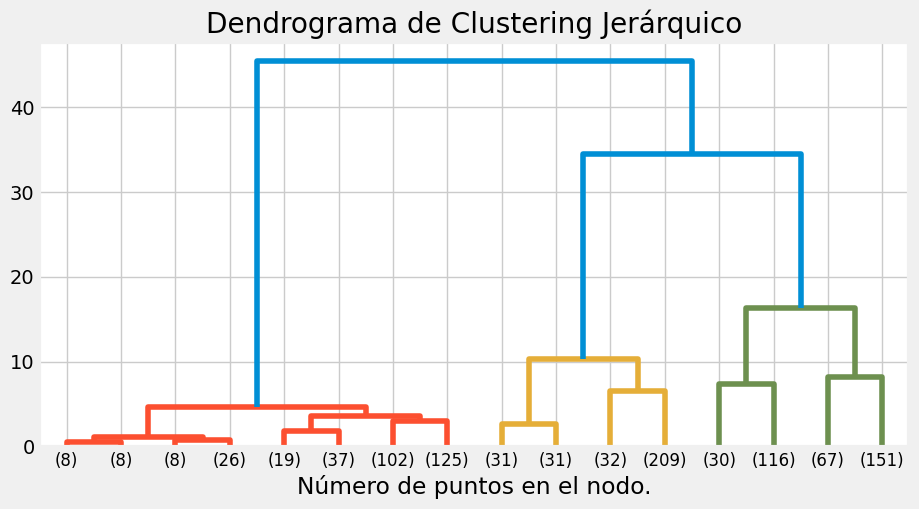

In [ ]:
plt.title("Dendrograma de Clustering Jerárquico")
# graficamos los primero p=5 niveles del dendrograma
plot_dendrogram( model_A, truncate_mode="level", p=3)
plt.xlabel("Número de puntos en el nodo.") # si solo hay un punto indica el indice sin parentesis
plt.show()

## **`MODELO B: CLUSTERING JERARQUICO - de la Data Sintética`**

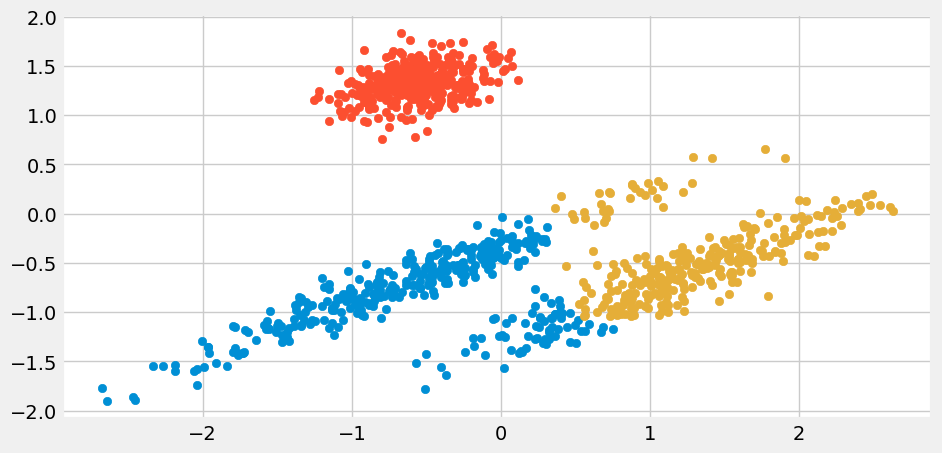

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from numpy import unique

# Una vez que decidimos el numero de clusters lo especificamos en n_clusters
model_B = AgglomerativeClustering(n_clusters=3)
yhat = model_B.fit_predict(X)

clusters = unique(yhat)

for cluster in clusters:
 row_ix = where(yhat == cluster)
 pyplot.scatter(X[row_ix, 0], X[row_ix, 1])

pyplot.show()

## **`MODELO C: CLUSTERING JERARQUICO - de la Data de Acciones de Bolsa de Valores`**

In [ ]:
import matplotlib.cm as cm

<ipython-input-34-fd0d95bf18a3>:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ax.matshow(corr,cmap=cm.get_cmap('coolwarm'), vmin=0,vmax=1)


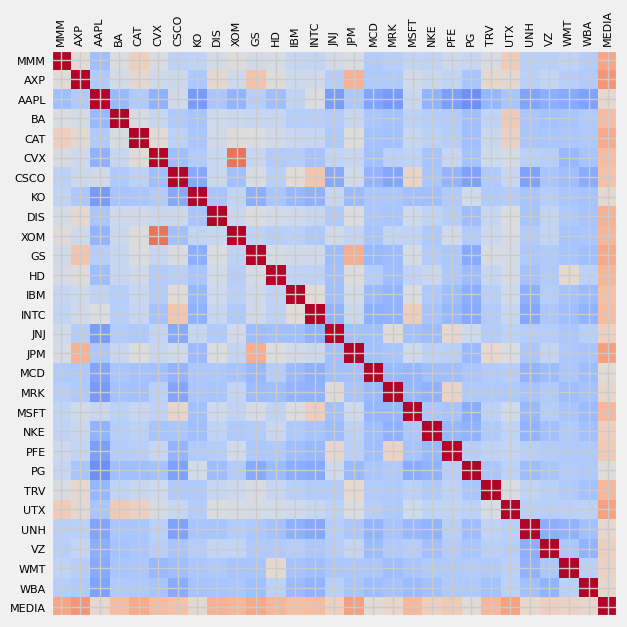

In [ ]:
corr = data.corr()
size = 7
fig, ax = plt.subplots(figsize=(size, size))
ax.matshow(corr,cmap=cm.get_cmap('coolwarm'), vmin=0,vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation='vertical', fontsize=8);
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8);

In [ ]:
corr

,MMM,AXP,AAPL,BA,CAT,CVX,CSCO,KO,DIS,XOM,...,NKE,PFE,PG,TRV,UTX,UNH,VZ,WMT,WBA,MEDIA
MMM,1.000000,0.519420,0.307200,0.487751,0.578462,0.481446,0.388405,0.399578,0.468584,0.508008,...,0.401768,0.438288,0.414093,0.482471,0.594654,0.378853,0.372886,0.396899,0.364081,0.715898
AXP,0.519420,1.000000,0.352361,0.465400,0.528225,0.447723,0.437272,0.340595,0.535249,0.444513,...,0.431561,0.407804,0.331315,0.537332,0.529976,0.378942,0.410621,0.368615,0.354729,0.757220
AAPL,0.307200,0.352361,1.000000,0.281480,0.350314,0.259904,0.452315,0.194118,0.333183,0.266097,...,0.269255,0.206184,0.163653,0.273502,0.329271,0.221260,0.249202,0.238139,0.214108,0.536708
BA,0.487751,0.465400,0.281480,1.000000,0.478080,0.422008,0.346383,0.326861,0.445153,0.435283,...,0.366157,0.360989,0.308054,0.397600,0.600781,0.335030,0.319057,0.329287,0.352272,0.649008
CAT,0.578462,0.528225,0.350314,0.478080,1.000000,0.517309,0.384010,0.332096,0.451405,0.501830,...,0.389616,0.367532,0.308474,0.432162,0.571543,0.334838,0.332725,0.336586,0.344036,0.699669
CVX,0.481446,0.447723,0.259904,0.422008,0.517309,1.000000,0.303540,0.358820,0.426709,0.829217,...,0.325664,0.414069,0.317788,0.441427,0.469698,0.380304,0.367868,0.281298,0.325139,0.653203
CSCO,0.388405,0.437272,0.452315,0.346383,0.384010,0.303540,1.000000,0.232116,0.435314,0.310941,...,0.334074,0.271990,0.210501,0.350928,0.415994,0.213765,0.329389,0.302613,0.239173,0.636187
KO,0.399578,0.340595,0.194118,0.326861,0.332096,0.358820,0.232116,1.000000,0.326116,0.402611,...,0.306909,0.354203,0.457491,0.350757,0.360914,0.329015,0.364773,0.334486,0.321177,0.534215
DIS,0.468584,0.535249,0.333183,0.445153,0.451405,0.426709,0.435314,0.326116,1.000000,0.428137,...,0.395780,0.364318,0.297936,0.414784,0.494157,0.325057,0.406450,0.345584,0.325951,0.686259
XOM,0.508008,0.444513,0.266097,0.435283,0.501830,0.829217,0.310941,0.402611,0.428137,1.000000,...,0.346154,0.451451,0.355565,0.439752,0.480032,0.361905,0.406533,0.324881,0.335232,0.669936


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linkage

<function scipy.cluster.hierarchy.linkage(y, method='single', metric='euclidean', optimal_ordering=False)>

In [ ]:
Z = linkage(corr, 'average')
Z

array([[ 5.        ,  9.        ,  0.27207065,  2.        ],
       [10.        , 15.        ,  0.45595649,  2.        ],
       [ 1.        , 30.        ,  0.53472591,  3.        ],
       [ 6.        , 13.        ,  0.55217128,  2.        ],
       [ 0.        , 23.        ,  0.59795924,  2.        ],
       [18.        , 32.        ,  0.63802964,  3.        ],
       [ 4.        , 33.        ,  0.6421695 ,  3.        ],
       [17.        , 20.        ,  0.65092769,  2.        ],
       [14.        , 36.        ,  0.6956485 ,  3.        ],
       [12.        , 34.        ,  0.71936254,  4.        ],
       [ 3.        , 35.        ,  0.73536588,  4.        ],
       [ 8.        , 31.        ,  0.76549928,  4.        ],
       [ 7.        , 21.        ,  0.78186826,  2.        ],
       [11.        , 26.        ,  0.78217715,  2.        ],
       [22.        , 40.        ,  0.79465521,  5.        ],
       [39.        , 43.        ,  0.83270992,  9.        ],
       [19.        , 42.

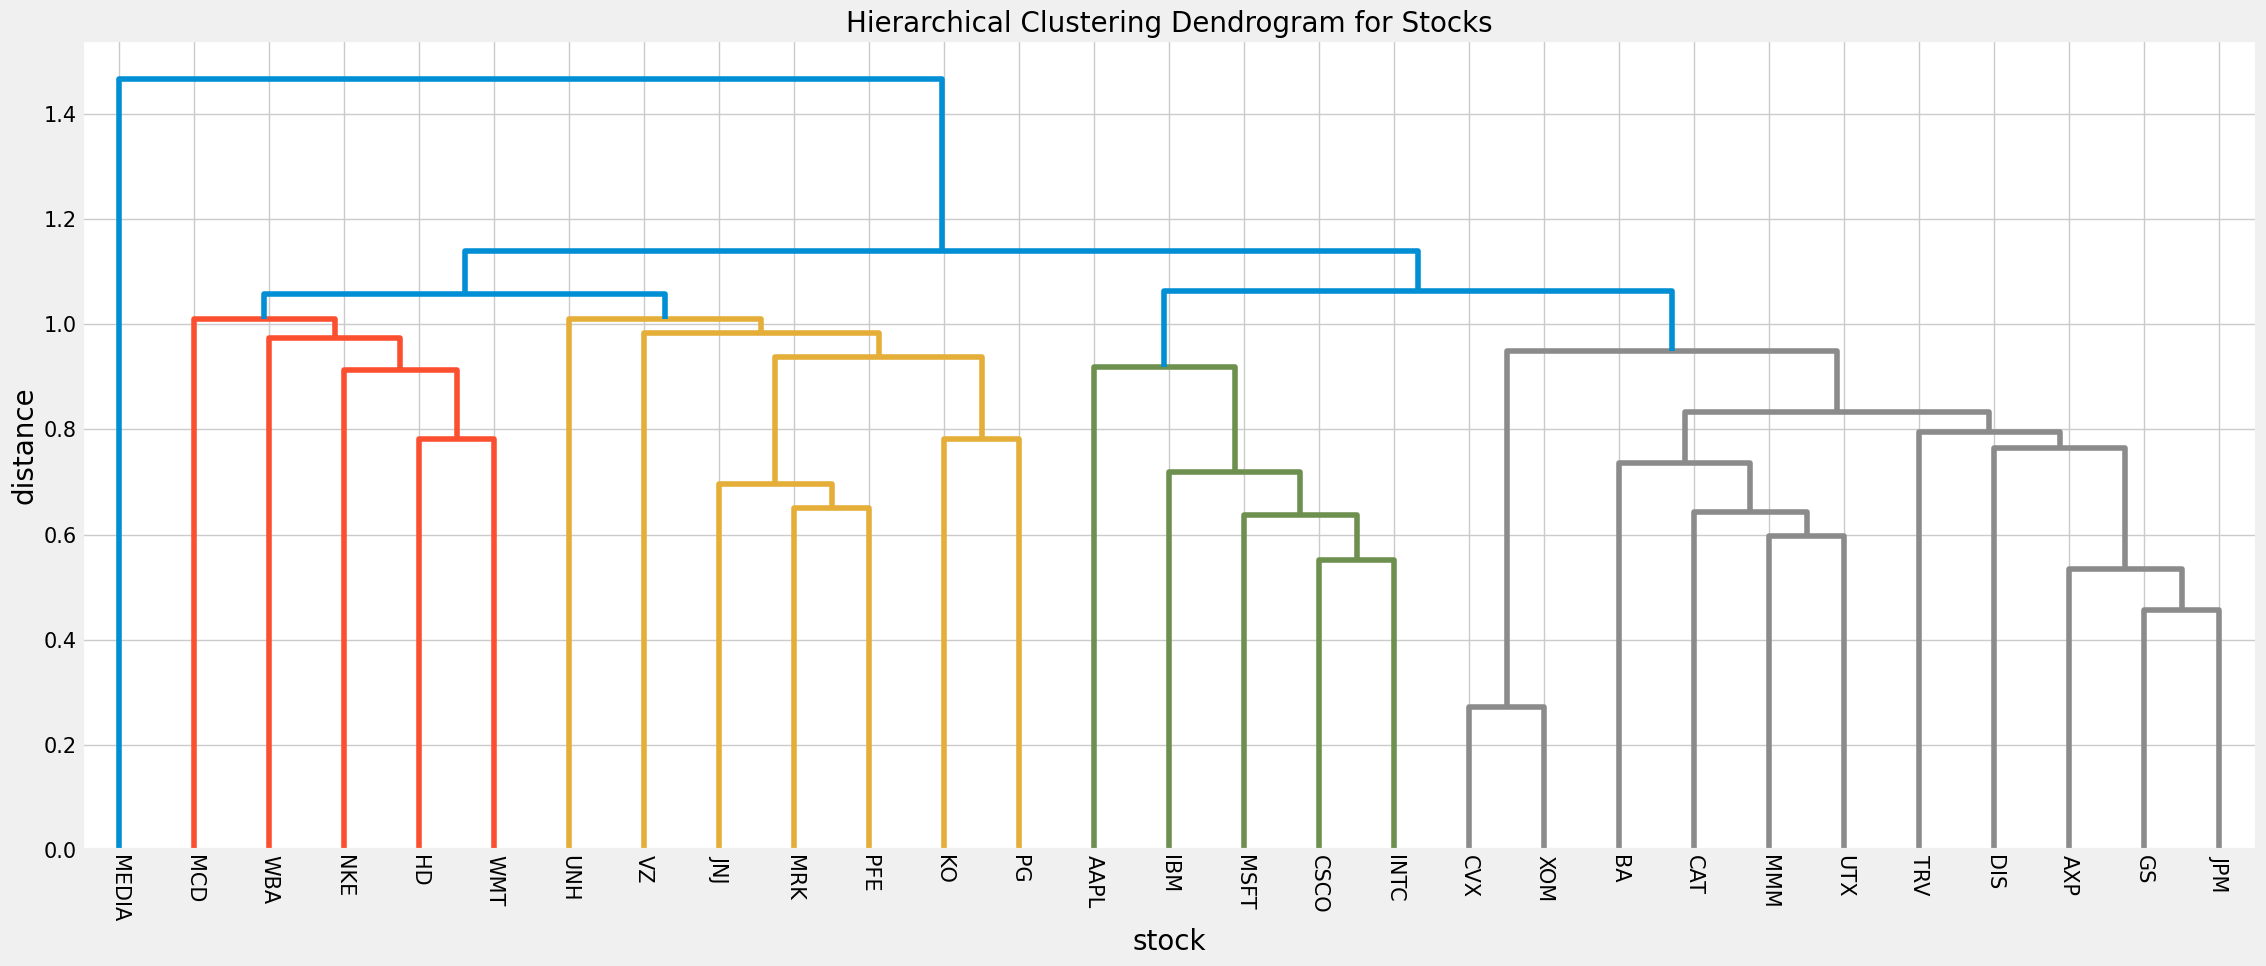

In [ ]:
import pylab
plt.figure(figsize=(25, 10))
labelsize=20
ticksize=15
plt.title('Hierarchical Clustering Dendrogram for '+"Stocks", fontsize=labelsize)
plt.xlabel('stock', fontsize=labelsize)
plt.ylabel('distance', fontsize=labelsize)
dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    labels = corr.columns
)
pylab.yticks(fontsize=ticksize)
pylab.xticks(rotation=-90, fontsize=ticksize)
plt.savefig('dendogram_'+'DJIA'+'.png')
plt.show()

In [ ]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import pdist
import pylab
c, coph_dists = cophenet(Z, pdist(corr))
c

np.float64(0.7996812457331596)

## **`MODELO D: CLUSTERING KMEANS - de la Data Sintética`**

In [ ]:
from sklearn.cluster import KMeans
KMeans

sklearn.cluster._kmeans.KMeans

### Crear modelo:

In [ ]:
# Seleccionamos el numero de clusters
Modelo1_KMeans = KMeans(n_clusters=3)
Modelo1_KMeans

KMeans(n_clusters=3)

### FIT (Ajustar, Entrenar):

In [ ]:
# Ajustamos el modelo
Modelo1_KMeans.fit(X)

KMeans(n_clusters=3)

### PREDICT (generar valores ajustados y/o predicción):

In [ ]:
# Asignamos un cluster a cada ejemplo
yhat = Modelo1_KMeans.predict(X)

In [ ]:
## ARRAY de Numpy
print(type( yhat ))
display(len( yhat )) # shape len
display( yhat[:10] )

<class 'numpy.ndarray'>


1000

array([0, 1, 0, 1, 1, 2, 1, 0, 0, 0], dtype=int32)

In [ ]:
## ARRAY de Numpy
print(type( y ))
display(len( y )) # shape len
display( y[:10] )

<class 'numpy.ndarray'>


1000

array([2, 1, 2, 1, 1, 0, 1, 2, 2, 2])

### EVALUAR MODELO

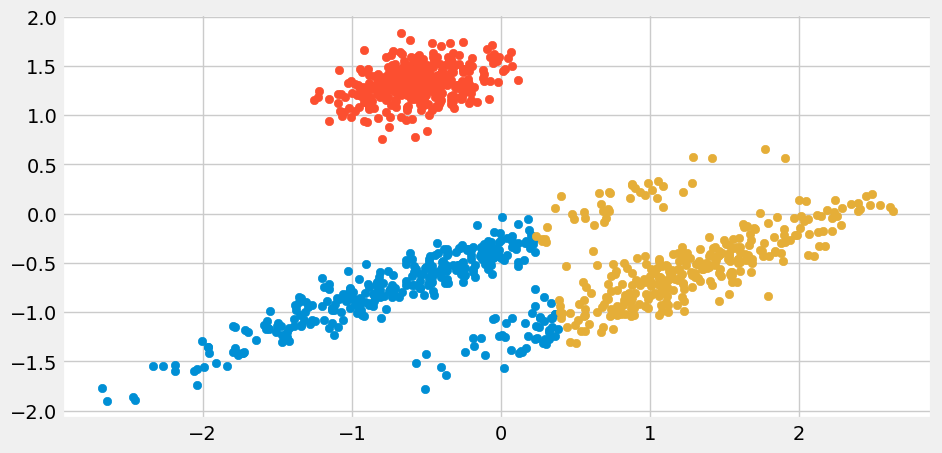

In [ ]:
# extraemos los cluster unicos
clusters = unique(yhat)
# creamos el diagrama de dispersion
for cluster in clusters:
 row_ix = where(yhat == cluster)
 pyplot.scatter(X[row_ix, 0], X[row_ix, 1])
# show the plot
pyplot.show()

## K-Means

### Conceptos Básicos de K-Means

- **K-Means** es uno de los algoritmos de clustering más populares y ampliamente utilizados. Su objetivo principal es dividir un conjunto de datos en **K grupos**, donde K es un número predefinido por el usuario.
- El algoritmo funciona de manera iterativa para asignar cada punto de datos al cluster más cercano en función de las distancias entre los puntos y los centroides de los clústeres.
- Los **centroides** son puntos que representan el centro de gravedad de un clúster y se actualizan en cada iteración para minimizar la distancia intraclúster.
- K-Means es un algoritmo de **centroides** porque genera puntos medios que se usan para la asignacion de los clusters.

### Cómo Funciona el Algoritmo

1. **Inicialización**: Selecciona K centroides iniciales de forma aleatoria o utilizando algún método específico (por ejemplo, K-Means++).
2. **Asignación**: Asigna cada punto de datos al clúster cuyo centroide es el más cercano.
3. **Actualización**: Recalcula los centroides de cada clúster como el promedio de todos los puntos asignados a ese clúster.
4. Repite los pasos 2 y 3 hasta que los centroides converjan o se alcance un número máximo de iteraciones.

![kmeans](https://www.learnbymarketing.com/wp-content/uploads/2015/01/method-k-means-steps-example.png)

### Ventajas y Desventajas

- **Ventajas**:
  - Fácil de entender e implementar.
  - Eficiente en términos de tiempo y escalabilidad.
  - Se puede adaptar a casos donde los clusters no son de similar tamaño o tienen distinta forma.

- **Desventajas**:
  - Sensible a la elección inicial de los centroides, lo que puede llevar a soluciones subóptimas.
  - No es adecuado para datos con clusters de formas irregulares o de tamaños significativamente diferentes.
  - Sensible a Valores extremos (Outliers) los valores extremos pueden alterar la posición de los centroides..



## **`MODELO D-2: CLUSTERING KMEANS - de la Data de Acciones`**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Convertimos la matriz de correlación a un formato apto para clustering
# Transponemos para que las columnas sean las características
X_stocks = data.T
X_stocks

Date,2000-01-04,2000-01-05,2000-01-06,2000-01-07,2000-01-10,2000-01-11,2000-01-12,2000-01-13,2000-01-14,2000-01-18,...,2019-01-24,2019-01-25,2019-01-28,2019-01-29,2019-01-30,2019-01-31,2019-02-01,2019-02-04,2019-02-05,2019-02-06
MMM,-2.783305,3.491453,3.995818,1.337698,-0.371257,-1.251948,0.171684,-0.034806,-1.057322,-1.553282,...,0.047934,1.179659,-0.988203,1.307861,0.780041,0.322746,-0.428509,0.329890,0.279606,0.463914
AXP,-1.714531,-0.250475,-0.021248,0.604016,0.624764,0.384001,-0.250741,0.209427,0.982782,-2.237757,...,-0.016760,0.449957,-0.194443,0.237325,0.736718,-0.008172,0.135620,0.135072,0.186454,0.435307
AAPL,-3.315064,0.522450,-3.400666,1.791770,-0.727008,-2.028461,-2.369508,4.206659,1.433906,1.306221,...,-0.352360,1.239921,-0.403870,-0.446916,2.604765,0.234227,-0.026372,1.056435,0.618435,-0.031653
BA,-0.118649,3.667073,0.108313,1.497066,-0.780316,-0.875641,0.034243,-0.875579,1.983881,1.163466,...,-0.089810,0.836560,-0.218399,0.243310,3.269320,-0.326336,0.208846,1.267959,1.717794,0.080400
CAT,-0.672149,1.828679,1.770951,1.573522,-1.653060,-0.808135,0.823258,0.502728,-0.269121,-1.624523,...,0.308092,1.503260,-4.537476,0.824622,1.363955,1.124453,-0.866733,-0.043981,0.389741,-0.578640
CVX,-0.030177,1.321853,2.389941,1.067883,-1.711071,-0.613077,-0.252617,0.553114,-0.429710,1.628503,...,1.158762,-0.189778,-0.609521,-0.219530,0.628987,0.876383,1.996753,0.692840,-0.165822,-0.343886
CSCO,-2.304726,0.305449,-1.119210,2.382987,1.482524,-1.233624,-1.042648,0.925916,0.522293,1.647609,...,0.120931,0.449938,-0.347608,0.173342,0.649644,0.491200,0.029868,-0.004491,-0.090261,0.175979
KO,0.236964,0.823741,-0.104682,5.050971,-2.486755,2.599554,0.851641,-1.202520,0.613257,4.953569,...,-0.950386,-0.541138,-0.349237,0.352525,0.724974,0.411568,0.889907,0.847538,-0.007913,-0.023575
DIS,3.089027,1.857074,-1.845881,-0.867545,8.090552,0.521966,-3.783446,1.741894,-1.936888,1.463419,...,-0.299494,0.233238,-0.160696,0.016594,-0.395973,0.644814,-0.131558,0.212369,0.382597,-0.616855
XOM,-1.283097,3.247575,3.696220,-0.216324,-0.944732,0.761983,-0.993360,1.504727,-1.324224,0.761983,...,0.068926,0.271446,-0.463488,0.225948,0.694062,0.877378,2.346087,-0.976238,0.653535,-0.310441


In [ ]:
# Aplicamos KMeans con 3 clusters (ajusta según evaluación)
kmeans_stocks = KMeans(n_clusters=4, random_state=0)
kmeans_stocks.fit(X_stocks)

# Resultados
labels = kmeans_stocks.labels_
print("Etiquetas de Clústeres:", labels)

# Evaluación rápida (opcional)
silhouette = silhouette_score(X_stocks, labels)
print("Silhouette Score:", silhouette)

Etiquetas de Clústeres: [0 0 2 0 0 0 2 1 0 0 0 3 2 2 1 0 3 1 2 0 0 1 0 0 0 0 3 3 0]
Silhouette Score: 0.054465160368766564


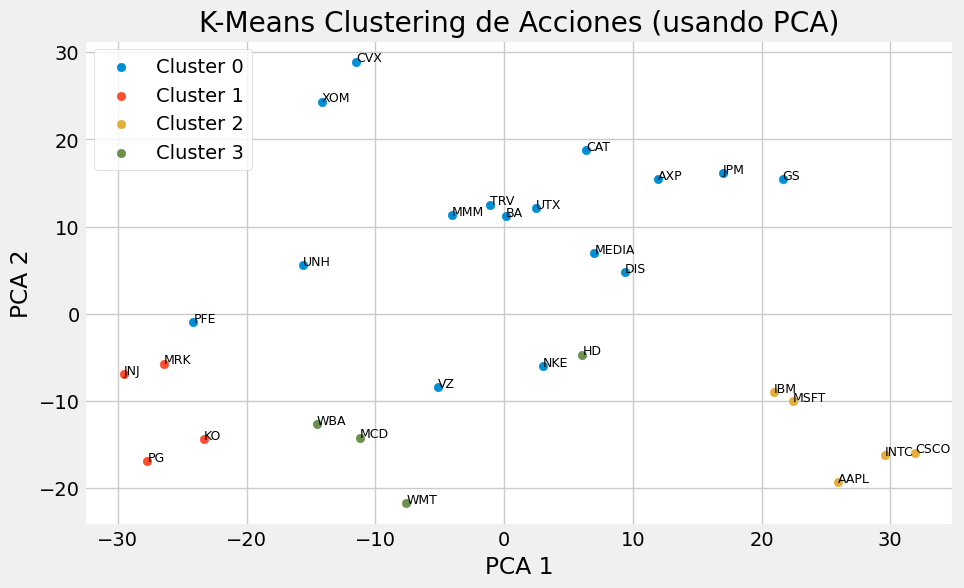

In [ ]:
# Reducción de dimensión para visualización (usamos PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X_stocks)

# Gráfico 2D
plt.figure(figsize=(10,6))
for i in range(4):
    plt.scatter(reduced_data[labels == i, 0], reduced_data[labels == i, 1], label=f'Cluster {i}')

# Etiquetas
for i, stock in enumerate(X_stocks.index):
    plt.text(reduced_data[i, 0], reduced_data[i, 1], stock, fontsize=9)

plt.title('K-Means Clustering de Acciones (usando PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()


**💡 Interpretación y usos del resultado**
Las acciones con la misma etiqueta de clúster son similares en su comportamiento normalizado de rendimientos.

**Puede ayudar a construir portafolios diversificados, seleccionando 1 acción por clúster.**

Se puede usar para identificar acciones redundantes o altamente correlacionadas.

## **`MODELO E: CLUSTERING MeanShift - de la Data Sintética`**

In [ ]:
from sklearn.cluster import MeanShift
MeanShift

sklearn.cluster._mean_shift.MeanShift

# Crear modelo

In [ ]:
# inicializamos con un ancho de banda W = 0.7
Modelo2_MeanShift = MeanShift(bandwidth=0.7,cluster_all = False)
Modelo2_MeanShift

MeanShift(bandwidth=0.7, cluster_all=False)

# FIT (Ajustar, Entrenar) y PREDICT (generar valores ajustados y/o predicción)

In [ ]:
%%time
yhat_MeanShift = Modelo2_MeanShift.fit_predict(X)

CPU times: user 4.74 s, sys: 45.6 ms, total: 4.78 s
Wall time: 4.78 s


In [ ]:
type(yhat_MeanShift)

numpy.ndarray

In [ ]:
yhat_MeanShift[:10]

array([ 2,  0, -1,  0,  0,  1,  0,  2,  2,  2])

# EVALUAR MODELO

In [ ]:
clusters = unique(yhat_MeanShift)
clusters

array([-1,  0,  1,  2])

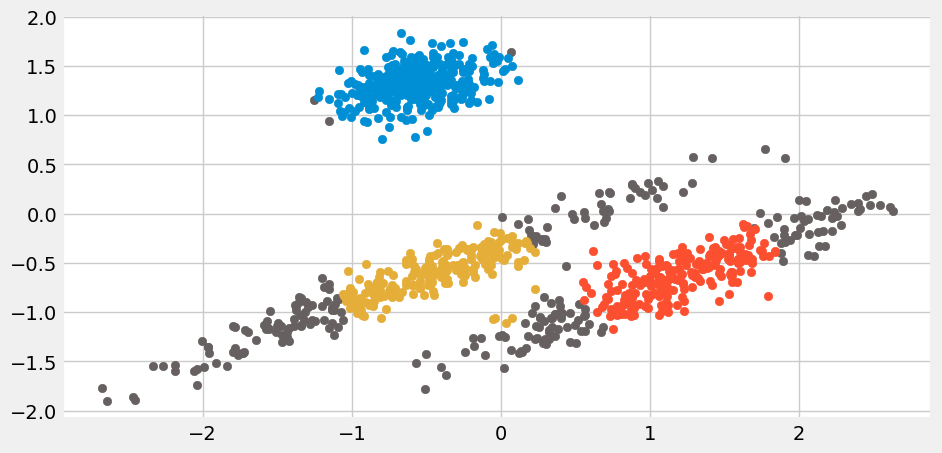

In [ ]:
for cluster in clusters:
 row_ix = where(yhat_MeanShift == cluster)
 if cluster == -1 : pyplot.scatter(X[row_ix, 0], X[row_ix, 1],c='#666160')
 else: pyplot.scatter(X[row_ix, 0], X[row_ix, 1])
pyplot.show()

## MeanShift

### Conceptos Básicos de MeanShift

- **MeanShift** es un algoritmo de clustering que se utiliza para encontrar los clusters en un conjunto de datos de manera no paramétrica, lo que significa que no es necesario especificar previamente el número de clusters K.
- A diferencia de K-Means, MeanShift no asume una forma específica para los clusters y puede encontrar clusters de formas arbitrarias.
- El algoritmo se basa en la idea de encontrar los "picos" en la densidad de puntos de datos y asignar los puntos a estos picos como sus clústeres.

### Cómo Funciona el Algoritmo

1. **Inicialización**: Se define el radio de busqueda W.
2. **Cálculo de Densidad**: Para cada punto candidato, calcula la densidad de puntos dentro del radio W alrededor de ese punto.
3. **Desplazamiento de Pico**: Mueve la ventana de busqueda hacia el centro de masa.
4. Repite los pasos 2 y 3 hasta que los puntos converjan a los picos.

![Meanshift_1](https://media.geeksforgeeks.org/wp-content/uploads/20190429214435/gd3.png)
![Meanshift_2](https://www.researchgate.net/publication/326242239/figure/fig3/AS:645578044231681@1530929208053/Intuitive-description-of-the-mean-shift-procedure-find-the-densest-regions-in-the.png)

### Ventajas y Desventajas

- **Ventajas**:
  - No es necesario especificar previamente el número de clusters (K).
  - Puede encontrar clusters de formas arbitrarias y tamaños diferentes.
  - Funciona bien en datos con densidades variables.

- **Desventajas**:
  - Puede ser computacionalmente costoso en conjuntos de datos grandes debido a la necesidad de calcular densidades.
  - Sensible al tamaño del radio de búsqueda W, cuyo calculo no es trivial.



## **`MODELO E-2: CLUSTERING MeanShift - de la Data de Acciones`**

In [ ]:
X_stocks = data.T  # Acciones como observaciones, columnas como features
X_stocks

Date,2000-01-04,2000-01-05,2000-01-06,2000-01-07,2000-01-10,2000-01-11,2000-01-12,2000-01-13,2000-01-14,2000-01-18,...,2019-01-24,2019-01-25,2019-01-28,2019-01-29,2019-01-30,2019-01-31,2019-02-01,2019-02-04,2019-02-05,2019-02-06
MMM,-2.783305,3.491453,3.995818,1.337698,-0.371257,-1.251948,0.171684,-0.034806,-1.057322,-1.553282,...,0.047934,1.179659,-0.988203,1.307861,0.780041,0.322746,-0.428509,0.329890,0.279606,0.463914
AXP,-1.714531,-0.250475,-0.021248,0.604016,0.624764,0.384001,-0.250741,0.209427,0.982782,-2.237757,...,-0.016760,0.449957,-0.194443,0.237325,0.736718,-0.008172,0.135620,0.135072,0.186454,0.435307
AAPL,-3.315064,0.522450,-3.400666,1.791770,-0.727008,-2.028461,-2.369508,4.206659,1.433906,1.306221,...,-0.352360,1.239921,-0.403870,-0.446916,2.604765,0.234227,-0.026372,1.056435,0.618435,-0.031653
BA,-0.118649,3.667073,0.108313,1.497066,-0.780316,-0.875641,0.034243,-0.875579,1.983881,1.163466,...,-0.089810,0.836560,-0.218399,0.243310,3.269320,-0.326336,0.208846,1.267959,1.717794,0.080400
CAT,-0.672149,1.828679,1.770951,1.573522,-1.653060,-0.808135,0.823258,0.502728,-0.269121,-1.624523,...,0.308092,1.503260,-4.537476,0.824622,1.363955,1.124453,-0.866733,-0.043981,0.389741,-0.578640
CVX,-0.030177,1.321853,2.389941,1.067883,-1.711071,-0.613077,-0.252617,0.553114,-0.429710,1.628503,...,1.158762,-0.189778,-0.609521,-0.219530,0.628987,0.876383,1.996753,0.692840,-0.165822,-0.343886
CSCO,-2.304726,0.305449,-1.119210,2.382987,1.482524,-1.233624,-1.042648,0.925916,0.522293,1.647609,...,0.120931,0.449938,-0.347608,0.173342,0.649644,0.491200,0.029868,-0.004491,-0.090261,0.175979
KO,0.236964,0.823741,-0.104682,5.050971,-2.486755,2.599554,0.851641,-1.202520,0.613257,4.953569,...,-0.950386,-0.541138,-0.349237,0.352525,0.724974,0.411568,0.889907,0.847538,-0.007913,-0.023575
DIS,3.089027,1.857074,-1.845881,-0.867545,8.090552,0.521966,-3.783446,1.741894,-1.936888,1.463419,...,-0.299494,0.233238,-0.160696,0.016594,-0.395973,0.644814,-0.131558,0.212369,0.382597,-0.616855
XOM,-1.283097,3.247575,3.696220,-0.216324,-0.944732,0.761983,-0.993360,1.504727,-1.324224,0.761983,...,0.068926,0.271446,-0.463488,0.225948,0.694062,0.877378,2.346087,-0.976238,0.653535,-0.310441


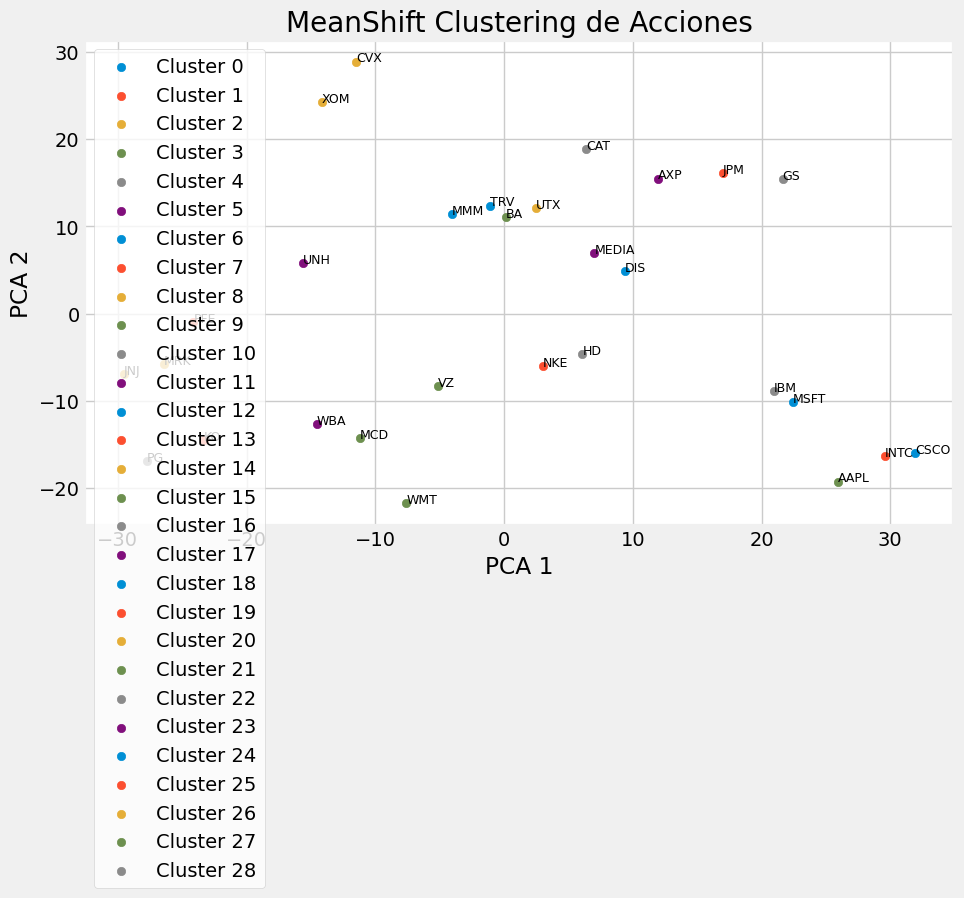

In [ ]:
from sklearn.cluster import MeanShift
from sklearn.decomposition import PCA

# Modelo
mean_shift = MeanShift(bandwidth=1.2)  # Ajusta el valor si da solo 1 cluster
labels_ms = mean_shift.fit_predict(X_stocks)

# Visualización 2D con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_stocks)

plt.figure(figsize=(10,6))
for cluster in np.unique(labels_ms):
    idx = labels_ms == cluster
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'Cluster {cluster}')

# Etiquetas de acciones
for i, stock in enumerate(X_stocks.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], stock, fontsize=9)

plt.title("MeanShift Clustering de Acciones")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()


## **`MODELO F: CLUSTERING DBSCAN - de la Data Sintética`**

In [ ]:
from sklearn.cluster import DBSCAN
DBSCAN

sklearn.cluster._dbscan.DBSCAN

# Crear modelo

In [ ]:
Modelo3_DBSCAN = DBSCAN(eps=0.25, min_samples=10)
Modelo3_DBSCAN

DBSCAN(eps=0.25, min_samples=10)

# FIT (Ajustar, Entrenar) y PREDICT (generar valores ajustados y/o predicción)

In [ ]:
%%time
yhat = Modelo3_DBSCAN.fit_predict(X)

CPU times: user 13.7 ms, sys: 0 ns, total: 13.7 ms
Wall time: 12.8 ms


# EVALUAR MODELO

In [ ]:
clusters_Modelo3_DBSCAN = unique(yhat)
clusters_Modelo3_DBSCAN

array([-1,  0,  1,  2])

# FIT (Ajustar, Entrenar) y PREDICT (generar valores ajustados y/o predicción)

In [ ]:
%%time
yhat = Modelo3_DBSCAN.fit_predict(X)

CPU times: user 14.8 ms, sys: 0 ns, total: 14.8 ms
Wall time: 13.6 ms


# EVALUAR MODELO

In [ ]:
clusters_Modelo3_DBSCAN = unique(yhat)
clusters_Modelo3_DBSCAN

array([-1,  0,  1,  2])

Explicación:

Iteración sobre los clusters:
El bucle for itera sobre cada uno de los clusters identificados por el algoritmo DBSCAN.
Obtención de los índices de las filas:
np.where(yhat == cluster)[0] devuelve los índices de las filas en la matriz X que pertenecen al cluster actual.
Asignación de colores:
Si el cluster es igual a -1, se asigna un color gris a los puntos correspondientes (c='#666160'). Esto suele utilizarse para representar puntos que no pertenecen a ningún cluster.
En caso contrario, se utiliza el color por defecto para los puntos.
Mostrar el gráfico:
pyplot.show() muestra el gráfico con los puntos coloreados según su pertenencia a los clusters.

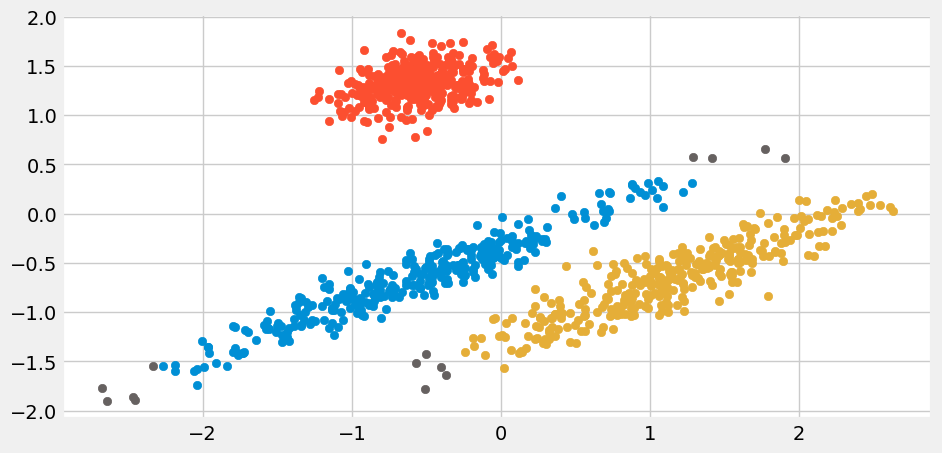

In [ ]:
for cluster in clusters_Modelo3_DBSCAN:
    # Obtener los índices de las filas que pertenecen al cluster actual
    row_ix = where(yhat == cluster)[0]

    # Si el cluster es -1, asignar un color gris a los puntos
    if cluster == -1:
        pyplot.scatter(X[row_ix, 0], X[row_ix, 1], c='#666160')
    # En caso contrario, asignar el color por defecto
    else:
        pyplot.scatter(X[row_ix, 0], X[row_ix, 1])

# Mostrar el gráfico
pyplot.show()

# FIT (Ajustar, Entrenar) y PREDICT (generar valores ajustados y/o predicción)

In [ ]:
%%time
yhat = Modelo3_DBSCAN.fit_predict(X)

CPU times: user 14.8 ms, sys: 0 ns, total: 14.8 ms
Wall time: 13.6 ms


# EVALUAR MODELO

In [ ]:
clusters_Modelo3_DBSCAN = unique(yhat)
clusters_Modelo3_DBSCAN

array([-1,  0,  1,  2])

Explicación:

Iteración sobre los clusters:
El bucle for itera sobre cada uno de los clusters identificados por el algoritmo DBSCAN.
Obtención de los índices de las filas:
np.where(yhat == cluster)[0] devuelve los índices de las filas en la matriz X que pertenecen al cluster actual.
Asignación de colores:
Si el cluster es igual a -1, se asigna un color gris a los puntos correspondientes (c='#666160'). Esto suele utilizarse para representar puntos que no pertenecen a ningún cluster.
En caso contrario, se utiliza el color por defecto para los puntos.
Mostrar el gráfico:
pyplot.show() muestra el gráfico con los puntos coloreados según su pertenencia a los clusters.

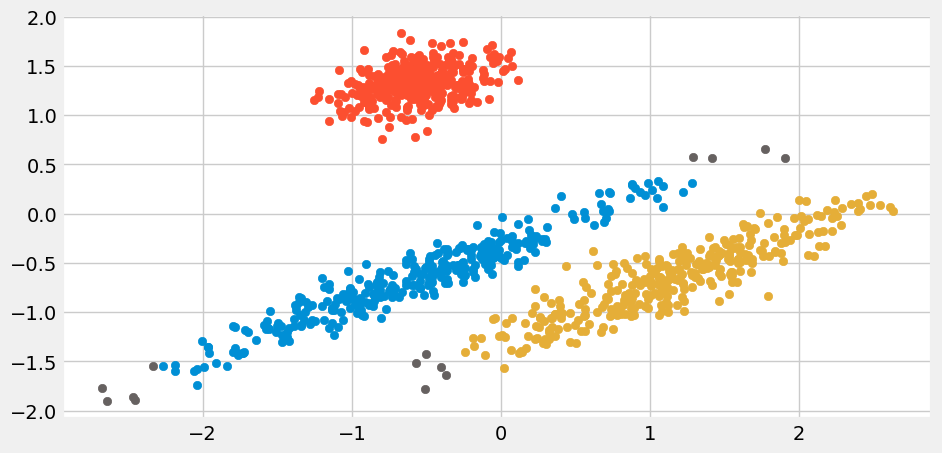

In [ ]:
for cluster in clusters_Modelo3_DBSCAN:
    # Obtener los índices de las filas que pertenecen al cluster actual
    row_ix = where(yhat == cluster)[0]

    # Si el cluster es -1, asignar un color gris a los puntos
    if cluster == -1:
        pyplot.scatter(X[row_ix, 0], X[row_ix, 1], c='#666160')
    # En caso contrario, asignar el color por defecto
    else:
        pyplot.scatter(X[row_ix, 0], X[row_ix, 1])

# Mostrar el gráfico
pyplot.show()

## DBSCAN

### Conceptos Básicos de DBSCAN

- **DBSCAN** es un algoritmo de clustering basado en densidad que se utiliza para identificar clusters en conjuntos de datos con densidades variables y formas arbitrarias.
- Al igual que MeanShift, DBSCAN no requiere especificar previamente el número de clusters (K) ni asumir una forma particular para los clusters.
- DBSCAN se basa en la idea de que un cluster se define como una región densa de puntos rodeada por una región de baja densidad.

### Cómo Funciona el Algoritmo

1. **Puntos Centrales**: Un punto se considera un **punto central** si dentro de un radio (épsilon, ε) alrededor de él, hay al menos un número mínimo de puntos (MinPts).

2. **Puntos de Borde**: Un punto se considera un **punto de borde** si está dentro del radio ε de un punto central, pero no cumple con el requisito de MinPts.

3. **Puntos de Ruido**: Los puntos que no son ni centrales ni de borde se consideran **puntos de ruido**.

4. **Conexión de Puntos**: Se forman clusters conectando puntos centrales y puntos de borde que están dentro del mismo radio ε hasta barrer todos los puntos.

![DBSCAN_1](https://miro.medium.com/proxy/1*tc8UF-h0nQqUfLC8-0uInQ.gif)

### Ventajas y Desventajas

- **Ventajas**:
  - Puede encontrar clusters de formas arbitrarias y tamaños diferentes.
  - Capaz de identificar puntos de ruido (datos atípicos) en el conjunto de datos.
  - No es necesario especificar previamente el número de clusters.

- **Desventajas**:
  - Sensible a la elección de los parámetros ε y MinPts, que deben ser ajustados adecuadamente.
  - Puede tener dificultades con conjuntos de datos de alta dimensionalidad.



## **`MODELO G: CLUSTERING DBSCAN - de la Data de Acciones`**

In [ ]:
from sklearn.cluster import DBSCAN

# Modelo DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=2)  # Ajusta según resultados

In [ ]:
labels_db = dbscan.fit_predict(X_stocks)


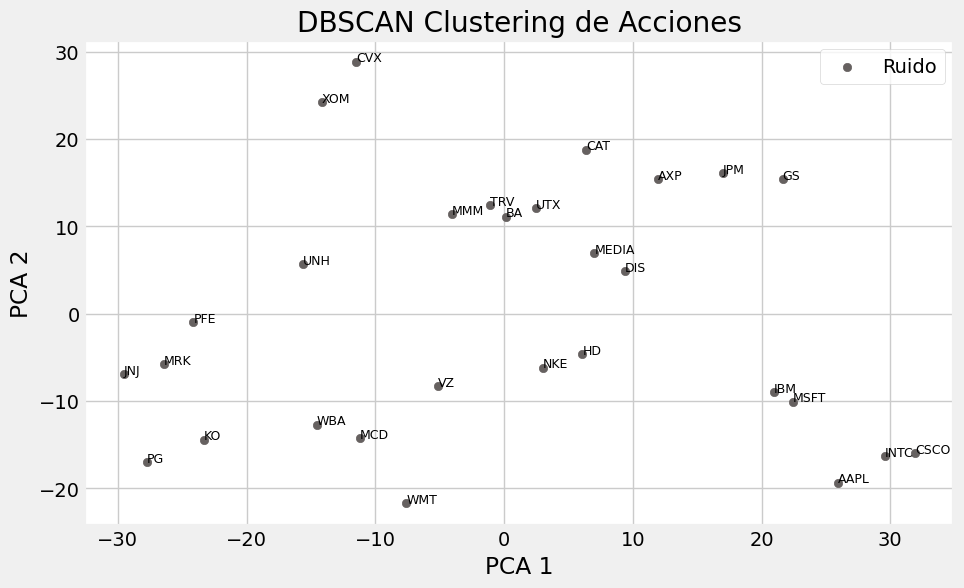

In [ ]:
# Visualización 2D con PCA
X_pca = PCA(n_components=2).fit_transform(X_stocks)

plt.figure(figsize=(10,6))
for cluster in np.unique(labels_db):
    idx = labels_db == cluster
    if cluster == -1:
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c='#666160', label='Ruido')
    else:
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f'Cluster {cluster}')

# Etiquetas de acciones
for i, stock in enumerate(X_stocks.index):
    plt.text(X_pca[i, 0], X_pca[i, 1], stock, fontsize=9)

plt.title("DBSCAN Clustering de Acciones")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()

# FIT (Ajustar, Entrenar) y PREDICT (generar valores ajustados y/o predicción)

In [ ]:
%%time
yhat = Modelo3_DBSCAN.fit_predict(X)

CPU times: user 14.8 ms, sys: 0 ns, total: 14.8 ms
Wall time: 13.6 ms


# EVALUAR MODELO

In [ ]:
clusters_Modelo3_DBSCAN = unique(yhat)
clusters_Modelo3_DBSCAN

array([-1,  0,  1,  2])

Explicación:

Iteración sobre los clusters:
El bucle for itera sobre cada uno de los clusters identificados por el algoritmo DBSCAN.
Obtención de los índices de las filas:
np.where(yhat == cluster)[0] devuelve los índices de las filas en la matriz X que pertenecen al cluster actual.
Asignación de colores:
Si el cluster es igual a -1, se asigna un color gris a los puntos correspondientes (c='#666160'). Esto suele utilizarse para representar puntos que no pertenecen a ningún cluster.
En caso contrario, se utiliza el color por defecto para los puntos.
Mostrar el gráfico:
pyplot.show() muestra el gráfico con los puntos coloreados según su pertenencia a los clusters.

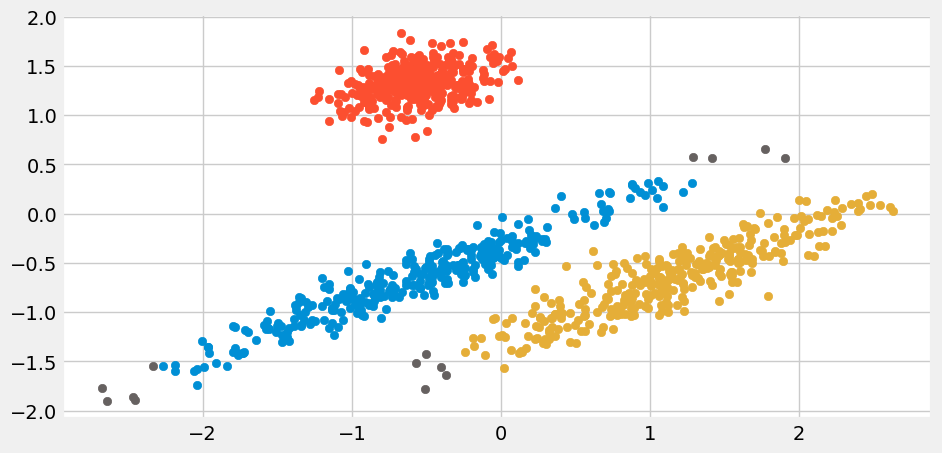

In [ ]:
for cluster in clusters_Modelo3_DBSCAN:
    # Obtener los índices de las filas que pertenecen al cluster actual
    row_ix = where(yhat == cluster)[0]

    # Si el cluster es -1, asignar un color gris a los puntos
    if cluster == -1:
        pyplot.scatter(X[row_ix, 0], X[row_ix, 1], c='#666160')
    # En caso contrario, asignar el color por defecto
    else:
        pyplot.scatter(X[row_ix, 0], X[row_ix, 1])

# Mostrar el gráfico
pyplot.show()

# **INTERPRETACION:** De resultados

¿Cuál ha sido los 2 mejores modelos para cada caso?

¿Por qué?